## Практическая работа 2_2
### Решить задачу своего варианта, используя нижеследующий код, выполнив шаги:

### 1) Определить случайную величину X, которая соответствует условию задачи и применению к решению ЦПТ;

### 2) Сгенерировать выборки из распределения, соответствующего формированию случайной величины X; 

### 3) Построить гистограмму для 3000 значений данной случайной величины, найденных по выборкам;

### 4) На этом же графике построить функцию плотности стандартного нормального распределения;

### 5) Вычислить вероятность, указанную в условии задачи, используя функцию распределения стандартной нормальной случайной величины
### norm.cdf()


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns
from scipy.stats import expon, norm, poisson, binom, uniform,bernoulli

/var/folders/rl/91_2kkn907g85_y2x8zslp3c0000gn/T/ipykernel_82978/3737049845.py:14: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_sum, bins=30,label =f'n= {n}')


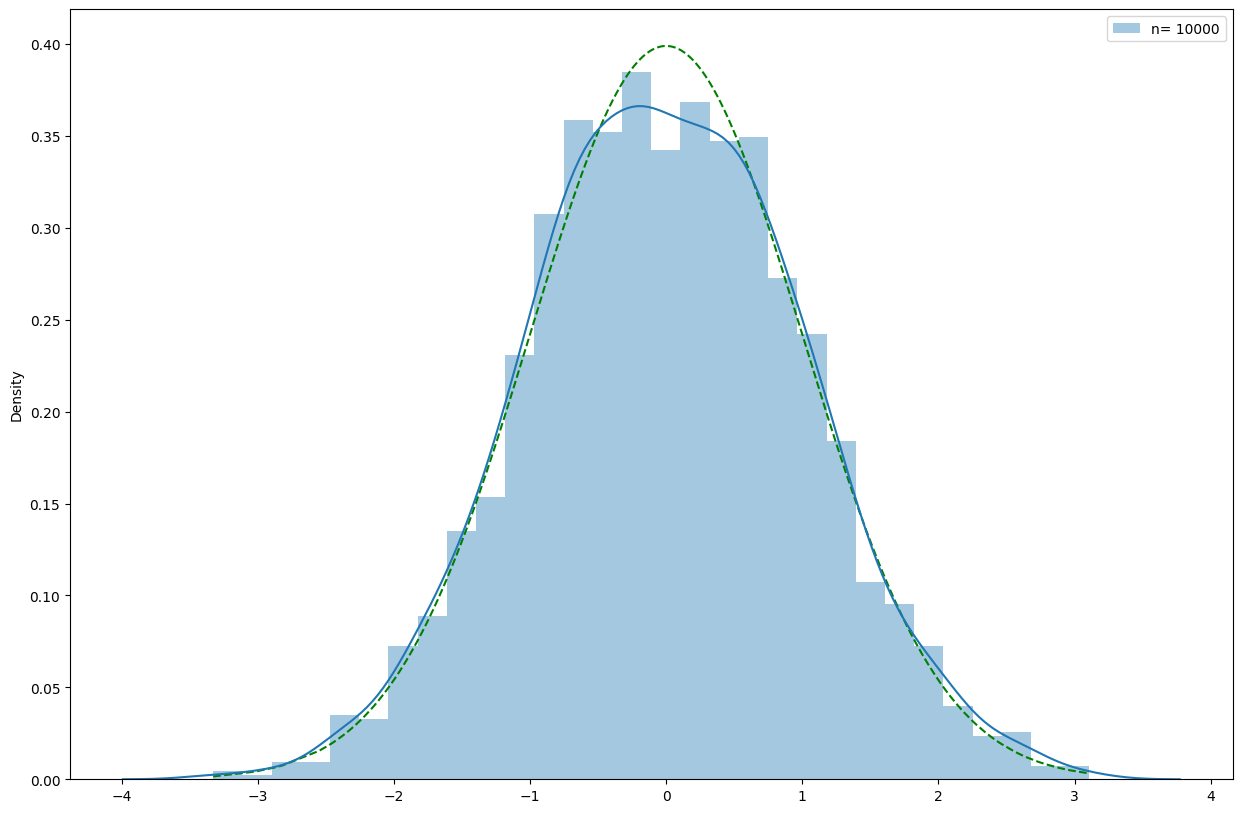

In [2]:
np.random.seed(123)
plt.figure(figsize=(15, 10))
n= 10000
m = 2000                                              # количество независимых выборок равного объема n
a =uniform.stats(loc=0, scale=1)[0]                   #матожидание
d= uniform.stats(loc=0, scale=1)[1]                   #дисперсия
x_sum = np.empty(m)                                   # вектор, который будет содержать сумму выборок
for i in range(0, m):
    x = uniform.rvs(loc=0,scale=1,size=n)
    x_sum[i] = (np.sum(x)-n*a)/math.sqrt(d*n)
x_sum = np.sort(x_sum)                                # отсортируем реализации выборочных сумм
f_x = norm.pdf(x_sum,loc =0,scale = 1)                #при помощи ЦПТ находим предельное распределение выборочной суммы
plt.plot(x_sum, f_x, '--', markersize = 20, color = 'green') # график теоретической функции распределения (по ЦПТ)
sns.distplot(x_sum, bins=30,label =f'n= {n}')
plt.legend();    

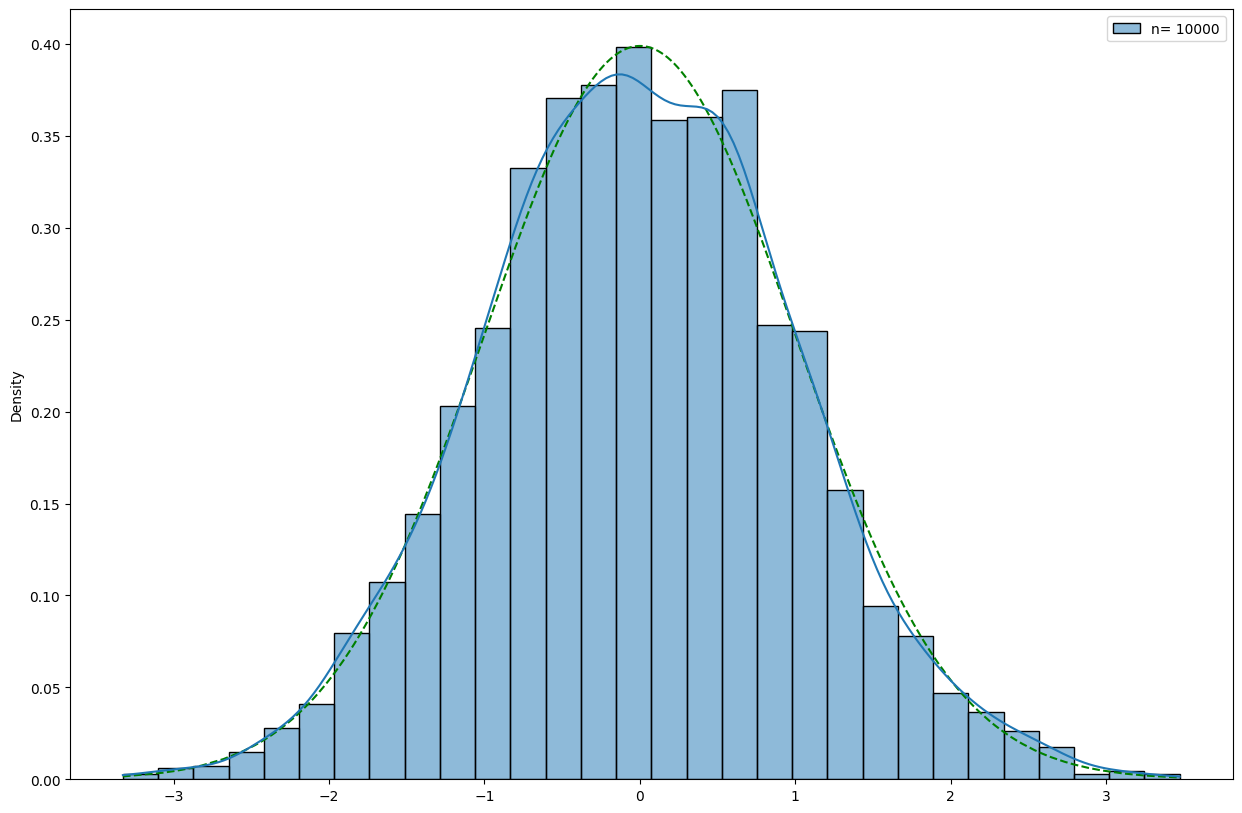

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns
from scipy.stats import expon, norm, poisson, binom, uniform, bernoulli

np.random.seed(123)
plt.figure(figsize=(15, 10))
n= 100000
m = 3000                                           # количество выборок 
a = uniform.stats(loc=0, scale=1)[0]               #матожидание (mean)
d = uniform.stats(loc=0, scale=1)[1]               #дисперсия (variance)
x_sum = np.empty(m)                                # вектор для хранения нормированных сумм
for i in range(0, m):
    x = uniform.rvs(loc=0, scale=1, size=n)        # генерируем случайные числа
    # формула ЦПТ: из суммы вычитаем среднее и делим на стандартное отклонение:
    x_sum[i] = (np.sum(x)-n*a)/math.sqrt(d*n)
x_sum = np.sort(x_sum)                             # сортировка для плавности графика
f_x = norm.pdf(x_sum, loc =0, scale = 1)           # плотность нормального распределения
plt.plot(x_sum, f_x, '--', markersize = 20, color = 'green') # теоретическая кривая
# histplot с параметром density=True заменяет старый distplot:
sns.histplot(x_sum, bins=30, stat="density", kde=True, label=f'n= {n}')
plt.legend();
plt.show()

#Если вы возьмете большое количество независимых случайных величин (с любым распределением!) и сложите их, то их сумма
#  (или среднее арифметическое) будет иметь распределение, очень близкое к нормальному.

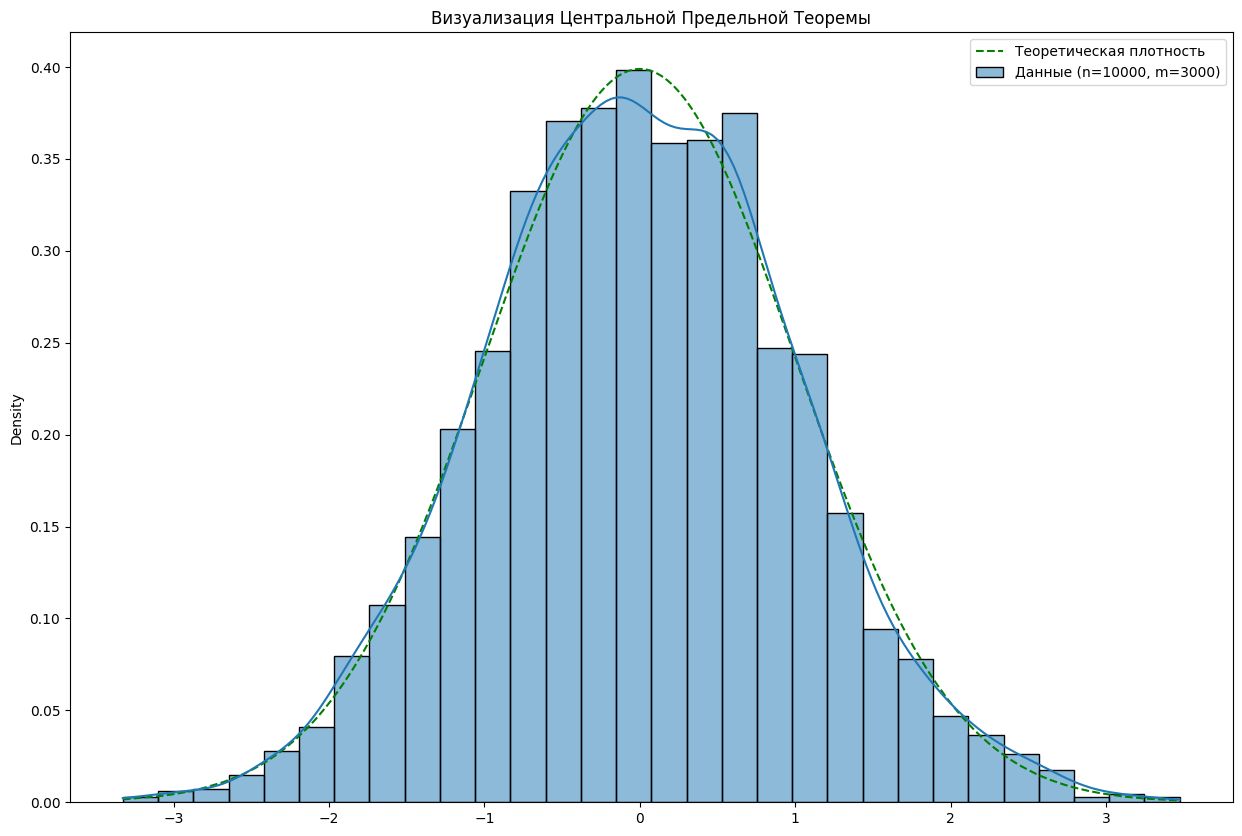

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns
from scipy.stats import expon, norm, poisson, binom, uniform, bernoulli

# Фиксируем генератор случайных чисел для повторяемости результата
np.random.seed(123)
plt.figure(figsize=(15, 10))

n = 10000        # Объем одной выборки (количество слагаемых в одной сумме)
m = 3000         # Количество экспериментов (сколько точек мы поставим на гистограмму)

# Берем параметры исходного распределения (в данном случае равномерного на [0, 1])
a = uniform.stats(loc=0, scale=1)[0]  # Теоретическое среднее (для [0,1] это 0.5)
d = uniform.stats(loc=0, scale=1)[1]  # Теоретическая дисперсия (разброс данных)

x_sum = np.empty(m)                   # Создаем пустой массив, куда сохраним 3000 результатов

for i in range(0, m):
    # 1. Генерируем n случайных чисел
    x = uniform.rvs(loc=0, scale=1, size=n)
    
    # 2. Согласно ЦПТ, центрируем сумму (вычитаем n*a) и нормируем (делим на корень из n*d).
    # Это приводит любую сумму к стандарту: среднее = 0, отклонение = 1.
    x_sum[i] = (np.sum(x) - n * a) / math.sqrt(d * n)

# Сортируем массив, чтобы линия теоретической плотности (f_x) легла ровно по графику
x_sum = np.sort(x_sum)

# Считаем значения "идеального" нормального распределения для наших точек
f_x = norm.pdf(x_sum, loc=0, scale=1)

# Рисуем зеленую пунктирную линию — это то, как гистограмма должна выглядеть в теории
plt.plot(x_sum, f_x, '--', markersize=20, color='green', label='Теоретическая плотность')

# Строим гистограмму наших 3000 сумм. 
# stat="density" обязателен: он переводит количество попаданий в вероятность (масштаб от 0 до 1),
# чтобы данные совпали с графиком f_x. kde=True рисует плавную огибающую линию.
sns.histplot(x_sum, bins=30, stat="density", kde=True, label=f'Данные (n={n}, m={m})')

plt.title("Визуализация Центральной Предельной Теоремы")
plt.legend()
plt.show()

# Суть кода: Мы взяли "неправильное" распределение (равномерное), но сложив 10 000 чисел, 
# получили "правильный" колокол нормального распределения. ЦПТ в действии.